This project uses the `Credit Card Fraud Detection Dataset 2023` which contains credit card transactions made by European cardholders in the year 2023. It comprises **over 550,000 records**, and the data has been anonymized to protect the cardholders' identities. The primary objective of this dataset is to facilitate the development of fraud detection algorithms and models to identify potentially fraudulent transactions.

Key Features:
- `id` : Unique identifier for each transaction
- `V1-V28` : Anonymized features representing various transaction attributes (e.g., time, location, etc.)
- `Amount` : The transaction amount
- `Class` : Binary label indicating whether the transaction is fraudulent (1) or not (0)

*Data Source: The dataset was collected from credit card transactions made by European cardholders in 2023, with sensitive information removed to ensure privacy and compliance with ethical guidelines.*
https://www.kaggle.com/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023

In [ ]:
#importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

In [ ]:
pip install xgboost lightgbm

# Exploratory Data Analysis (EDA)

In [ ]:
original = pd.read_csv('creditcard_2023.csv')
df = original.copy()
df.head(10)

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0
5,5,0.025302,-0.140514,1.191138,-0.707979,0.430490,0.458973,0.611050,-0.092629,0.180811,...,-0.187739,-0.538518,-0.050465,-0.631553,-0.456480,0.252670,0.066681,0.095812,6901.49,0
6,6,1.016482,-0.397181,0.497868,-0.144463,0.331022,0.629243,0.431262,-0.134007,0.796159,...,-0.171137,-0.287017,-0.178197,-1.297597,1.182503,-0.604228,-0.198163,-0.087619,18954.45,0
7,7,-0.051306,-0.007194,1.139941,-0.877880,0.684668,0.714326,0.892615,-0.908409,0.901938,...,0.620676,-0.920426,0.034660,-1.091527,-0.742075,-0.104863,-1.382522,-2.748268,12298.23,0
8,8,-0.130680,-0.349547,0.425786,-0.760444,1.702777,2.324816,0.568968,0.049100,0.273118,...,-0.132787,-0.284700,-0.227779,2.248754,0.534846,-0.929738,-0.224385,0.243790,22052.90,0
9,9,0.058419,-0.093507,1.117270,-0.735172,0.466111,0.332371,0.683425,-0.136674,0.096409,...,-0.203634,-0.601581,-0.145082,-0.654783,-0.196621,0.226818,0.057119,0.100629,210.35,0


In [ ]:
df.shape

(568630, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [ ]:
df.describe(include='all')

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.638058e-17,-1.319545e-16,-3.518788e-17,-2.879008e-17,7.997245e-18,-3.958636e-17,-3.198898e-17,2.109273e-17,3.998623e-17,...,4.758361e-17,3.948640e-18,6.194741e-18,-2.799036e-18,-3.178905e-17,-7.497417e-18,-3.598760e-17,2.609101e-17,12041.957635,0.5
std,164149.486121,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222e+00,-9.952786e+00,-2.111111e+01,-4.351839e+00,-1.075634e+01,-3.751919e+00,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-6.560203e-01,-2.934955e-01,-4.458712e-01,-2.835329e-01,-1.922572e-01,-5.687446e-01,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-7.376152e-02,8.108788e-02,7.871758e-02,2.333659e-01,-1.145242e-01,9.252647e-02,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,7.070047e-01,4.397368e-01,4.977881e-01,5.259548e-01,4.729905e-02,5.592621e-01,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536e+00,4.271689e+01,2.616840e+01,2.178730e+02,5.958040e+00,2.027006e+01,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


In [ ]:
#check unique values
df.nunique()

,0
id,568630
V1,552035
V2,552035
V3,552035
V4,552035
V5,552035
V6,552035
V7,552035
V8,552035
V9,552035


In [ ]:
#check missing values
df.isnull().sum()

,0
id,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
#check categorical and numerical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
[]
Numerical Variables:
['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


Class
0    284315
1    284315
Name: count, dtype: int64

Class percentages:
Class
0    50.0
1    50.0
Name: count, dtype: float64


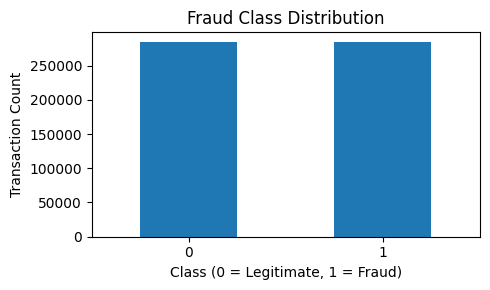

In [ ]:
#visualize the distribution of the target variable 'Class'
class_counts = df['Class'].value_counts().sort_index()
print(class_counts)
print("\nClass percentages:")
print((class_counts / len(df) * 100).round(2))

plt.figure(figsize=(5, 3))
class_counts.plot(kind='bar')
plt.title('Fraud Class Distribution')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Transaction Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Top 10 features by absolute correlation with Class:
V14   -0.805669
V12   -0.768579
V4     0.735981
V11    0.724278
V3    -0.682095
V10   -0.673665
V9    -0.585522
V16   -0.573511
V1    -0.505761
V2     0.491878
Name: Class, dtype: float64


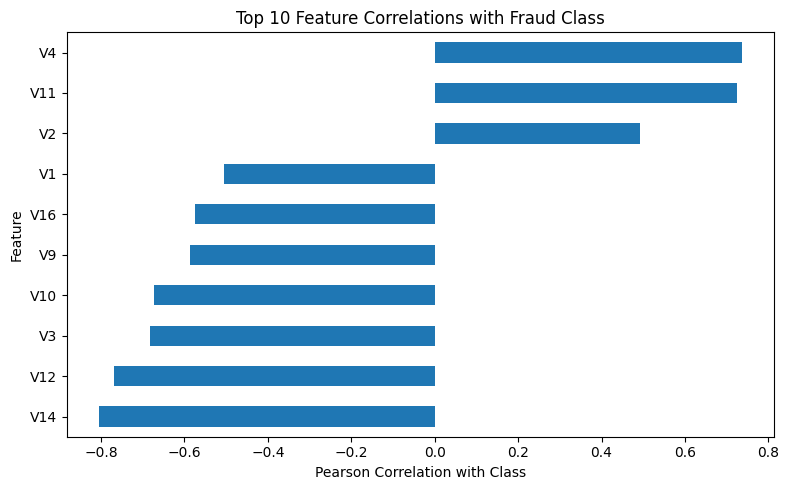

In [ ]:
#identify features with the strongest linear relationship to the fraud label
feature_cols = [col for col in df.columns if col.startswith('V')]
class_correlations = (
    df[feature_cols + ['Amount', 'Class']]
    .corr(numeric_only=True)['Class']
    .drop('Class')
    .sort_values(key=np.abs, ascending=False)
)

print("Top 10 features by absolute correlation with Class:")
print(class_correlations.head(10))

plt.figure(figsize=(8, 5))
class_correlations.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Feature Correlations with Fraud Class')
plt.xlabel('Pearson Correlation with Class')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
#duplicate transactions and amount analysis
duplicates_without_id = df.drop(columns=['id']).duplicated().sum()
print("Duplicate transactions excluding id:", duplicates_without_id)

amount_summary = df.groupby('Class')['Amount'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

print("\nAmount summary by Class:")
display(amount_summary)

Duplicate transactions excluding id: 1

Amount summary by Class:


,count,mean,median,std,min,max
Class,,,,,,
0,284315,12026.313506,11996.90,6929.500715,50.12,24039.93
1,284315,12057.601763,12062.45,6909.750891,50.01,24039.93


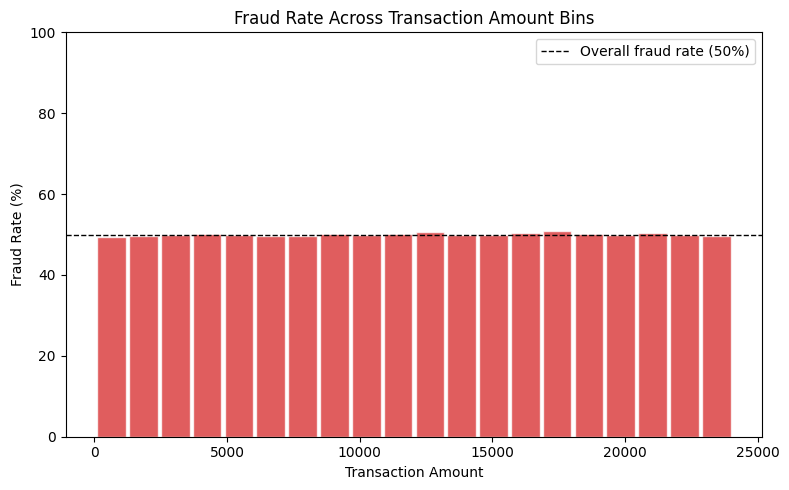

In [ ]:
#fraud rate across transaction amount bins
n_bins = 20
bins = np.linspace(df['Amount'].min(), df['Amount'].max(), n_bins + 1)
amount_bin = pd.cut(df['Amount'], bins=bins, include_lowest=True)

fraud_rate_by_bin = df.groupby(amount_bin, observed=True)['Class'].mean() * 100
bin_centers = [interval.mid for interval in fraud_rate_by_bin.index]

plt.figure(figsize=(8, 5))
plt.bar(bin_centers, fraud_rate_by_bin.values, width=(bins[1] - bins[0]) * 0.9,
        color='#d62728', alpha=0.75, edgecolor='white')
plt.axhline(50, color='black', linestyle='--', linewidth=1, label='Overall fraud rate (50%)')
plt.title('Fraud Rate Across Transaction Amount Bins')
plt.xlabel('Transaction Amount')
plt.ylabel('Fraud Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

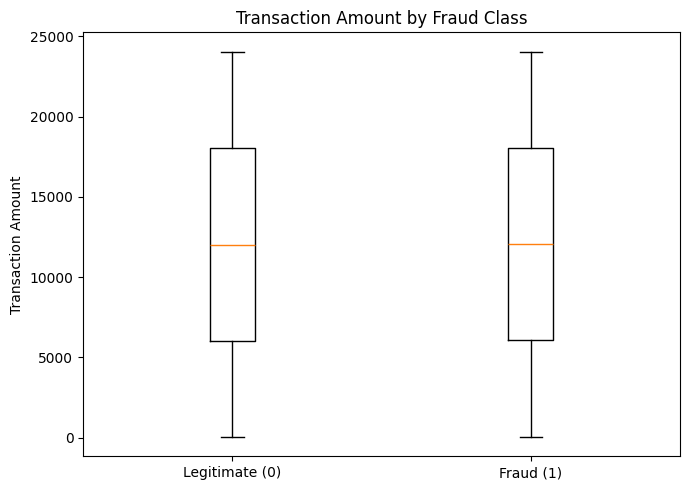

In [ ]:
#compare transaction amounts between legitimate and fraudulent classes
legitimate_amount = df.loc[df['Class'] == 0, 'Amount']
fraud_amount = df.loc[df['Class'] == 1, 'Amount']

plt.figure(figsize=(7, 5))
plt.boxplot([legitimate_amount, fraud_amount])
plt.xticks([1, 2], ['Legitimate (0)', 'Fraud (1)'])
plt.title('Transaction Amount by Fraud Class')
plt.ylabel('Transaction Amount')
plt.tight_layout()
plt.show()

# Data Preprocessing

In [ ]:
#remove the ID column because it is only a unique identifier
model_df = df.drop(columns=['id']).copy()
print("Shape before removing duplicates:", model_df.shape)

#remove duplicate transaction
model_df = model_df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", model_df.shape)
print("Total missing values:", model_df.isnull().sum().sum())

print("\nClass distribution after preprocessing:")
print(model_df['Class'].value_counts().sort_index())

print("\nClass percentages:")
print((model_df['Class'].value_counts(normalize=True).sort_index() * 100).round(4))

Shape before removing duplicates: (568630, 30)
Shape after removing duplicates: (568629, 30)
Total missing values: 0

Class distribution after preprocessing:
Class
0    284315
1    284314
Name: count, dtype: int64

Class percentages:
Class
0    50.0001
1    49.9999
Name: proportion, dtype: float64


In [ ]:
#separate predictors and target
X = model_df.drop(columns=['Class'])
y = model_df['Class']

#80:20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#make copies before scaling
X_train = X_train.copy()
X_test = X_test.copy()

#scale only Amount
scaler = StandardScaler()

X_train[['Amount']] = scaler.fit_transform(X_train[['Amount']])
X_test[['Amount']] = scaler.transform(X_test[['Amount']])

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set shape: (454903, 29)
Testing set shape: (113726, 29)

Training class distribution:
Class
0    227452
1    227451
Name: count, dtype: int64

Testing class distribution:
Class
1    56863
0    56863
Name: count, dtype: int64


In [ ]:
#preprocessing pipeline
#separate predictors and target from the cleaned, unscaled data
X_raw = model_df.drop(columns=['Class'])
y = model_df['Class']

#re-create the same 80:20 stratified train-test split using the unscaled data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#anonymized features
v_features = [f'V{i}' for i in range(1, 29)]

"""column-level preprocessing
v1-V28 are kept unchanged
amount is standardized using training data only """
preprocessor = ColumnTransformer(
    transformers=[
        ('v_features', 'passthrough', v_features),
        ('amount_scaler', StandardScaler(), ['Amount'])
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

#build preprocessing pipeline
preprocessing_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor)
    ]
)

#keep the transformed output as a pandas DataFrame
preprocessing_pipeline.set_output(transform='pandas')

#fit only on training data to prevent data leakage
X_train = preprocessing_pipeline.fit_transform(X_train_raw)

#apply the fitted preprocessing to test data
X_test = preprocessing_pipeline.transform(X_test_raw)

print("Preprocessing pipeline completed successfully.")

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nFeatures after preprocessing:")
print(X_train.columns.tolist())

print("\nAmount after StandardScaler (training data):")
print("Mean:", round(X_train['Amount'].mean(), 6))
print("Standard deviation:", round(X_train['Amount'].std(ddof=0), 6))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Preprocessing pipeline completed successfully.

Training set shape: (454903, 29)
Testing set shape: (113726, 29)

Features after preprocessing:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Amount after StandardScaler (training data):
Mean: 0.0
Standard deviation: 1.0

Training class distribution:
Class
0    227452
1    227451
Name: count, dtype: int64

Testing class distribution:
Class
1    56863
0    56863
Name: count, dtype: int64


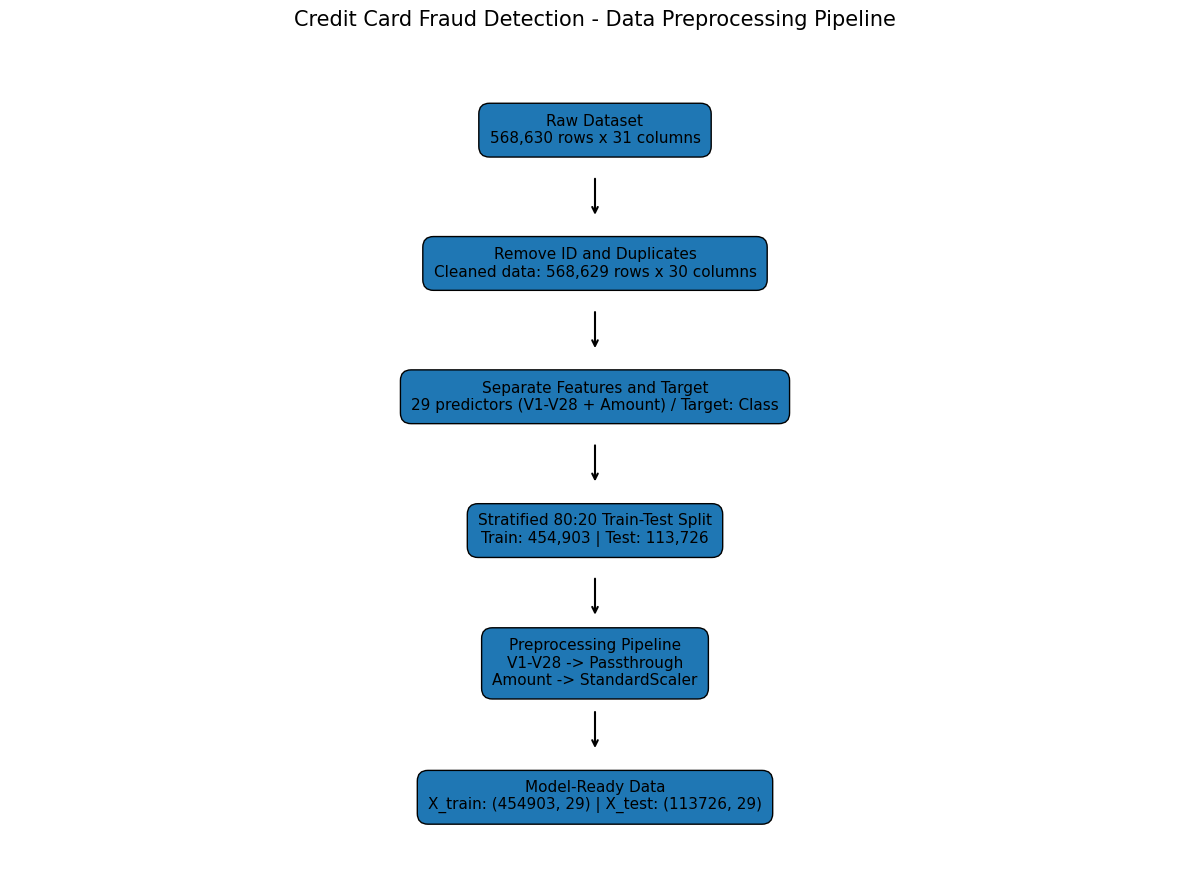

In [ ]:
steps = [
    (
        "Raw Dataset",
        f"{df.shape[0]:,} rows x {df.shape[1]} columns"
    ),
    (
        "Remove ID and Duplicates",
        f"Cleaned data: {model_df.shape[0]:,} rows x {model_df.shape[1]} columns"
    ),
    (
        "Separate Features and Target",
        f"{X_raw.shape[1]} predictors (V1-V28 + Amount) / Target: Class"
    ),
    (
        "Stratified 80:20 Train-Test Split",
        f"Train: {X_train_raw.shape[0]:,} | Test: {X_test_raw.shape[0]:,}"
    ),
    (
        "Preprocessing Pipeline",
        "V1-V28 -> Passthrough\nAmount -> StandardScaler"
    ),
    (
        "Model-Ready Data",
        f"X_train: {X_train.shape} | X_test: {X_test.shape}"
    )
]

fig, ax = plt.subplots(figsize=(12, 9))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

y_positions = np.linspace(0.90, 0.10, len(steps))

for i, ((title, description), y_pos) in enumerate(
    zip(steps, y_positions)
):
    ax.text(
        0.5,
        y_pos,
        f"{title}\n{description}",
        ha='center',
        va='center',
        fontsize=11,
        bbox=dict(
            boxstyle='round,pad=0.7'
        )
    )

    if i < len(steps) - 1:
        ax.annotate(
            '',
            xy=(0.5, y_positions[i + 1] + 0.055),
            xytext=(0.5, y_pos - 0.055),
            arrowprops=dict(
                arrowstyle='->',
                linewidth=1.5
            )
        )

plt.title(
    'Credit Card Fraud Detection - Data Preprocessing Pipeline',
    fontsize=15,
    pad=15
)

plt.tight_layout()
plt.show()

# Model Train & Evaluate

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=15,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=25,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    'SVM (SGDClassifier)': SGDClassifier(
        loss='log_loss',
        random_state=42,
        max_iter=1000,
        tol=1e-3,
        class_weight='balanced' # added for potentially imbalanced data
    )
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

print("\nAll baseline models have been trained.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [09:54:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training LightGBM...
[LightGBM] [Info] Number of positive: 227451, number of negative: 227452
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.273421 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 454903, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499999 -> initscore=-0.000004
[LightGBM] [Info] Start training from score -0.000004
Training SVM (SGDClassifier)...

All baseline models have been trained.


In [ ]:
#evaluate the models
results = []
predictions = {}
probabilities = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

display(
    results_df.style.format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1-score': '{:.4f}',
        'ROC-AUC': '{:.4f}'
    })
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.9648,0.9771,0.9519,0.9644,0.9935
1,Decision Tree,0.9956,0.9944,0.9968,0.9956,0.9972
2,Random Forest,0.9992,0.9993,0.9991,0.9992,1.0000
3,XGBoost,0.9997,0.9995,1.0000,0.9997,1.0000
4,LightGBM,0.9993,0.9985,1.0000,0.9993,0.9999
5,SVM (SGDClassifier),0.9648,0.9763,0.9528,0.9644,0.9932


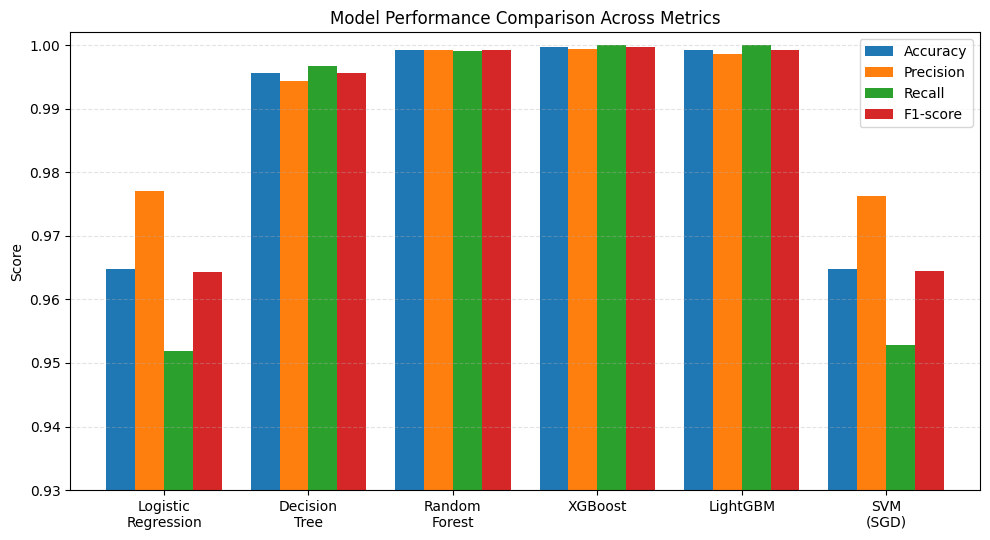

In [ ]:
#model performance comparison across metrics
metrics_to_plot = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-score'
]

#take the required metrics from the existing results table
performance_plot = results_df[
    ['Model'] + metrics_to_plot
].copy()

#shorter labels for a cleaner figure
performance_plot['Model'] = performance_plot['Model'].replace({
    'Logistic Regression': 'Logistic\nRegression',
    'Decision Tree': 'Decision\nTree',
    'Random Forest': 'Random\nForest',
    'SVM (SGDClassifier)': 'SVM\n(SGD)'
})

#grouped bar chart
ax = (
    performance_plot
    .set_index('Model')[metrics_to_plot]
    .plot(
        kind='bar',
        figsize=(10, 5.5),
        width=0.8
    )
)

ax.set_title('Model Performance Comparison Across Metrics')
ax.set_xlabel('')
ax.set_ylabel('Score')

#same range used to make the differences clearly visible
ax.set_ylim(0.93, 1.002)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.35
)

ax.legend(title='')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
for name in trained_models:
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=['Legitimate', 'Fraud']
        )
    )

Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.95      0.98      0.97     56863
       Fraud       0.98      0.95      0.96     56863

    accuracy                           0.96    113726
   macro avg       0.97      0.96      0.96    113726
weighted avg       0.97      0.96      0.96    113726

Decision Tree
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56863
       Fraud       0.99      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00   

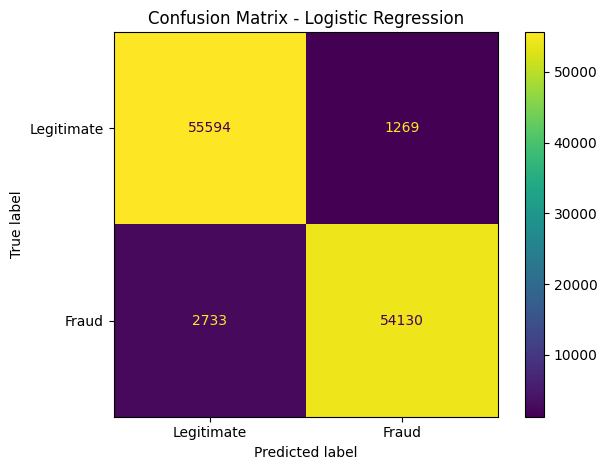

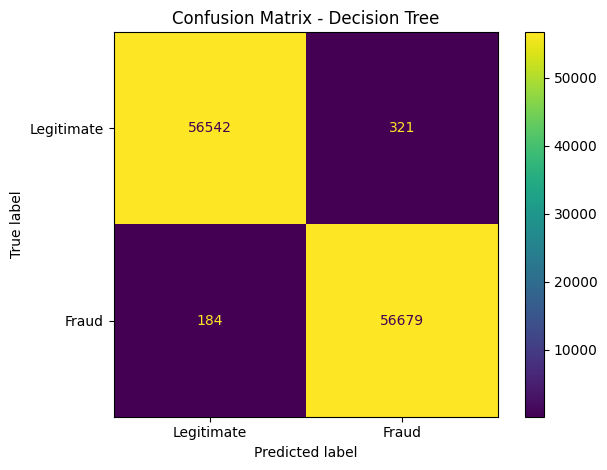

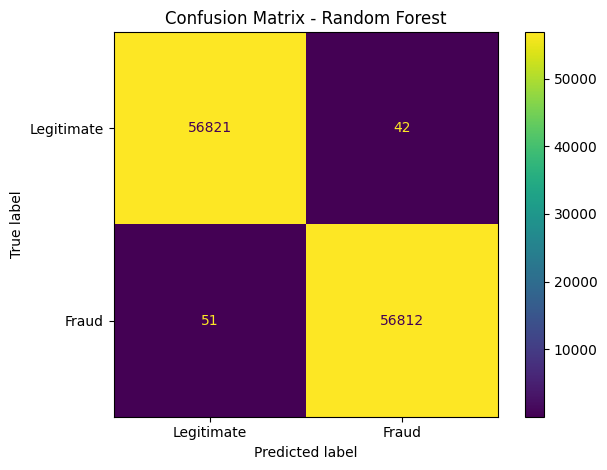

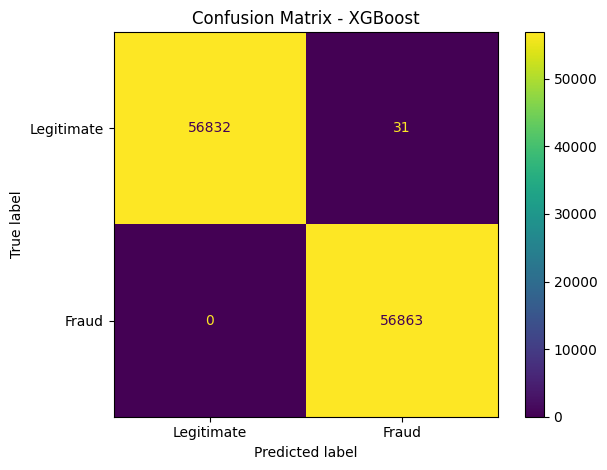

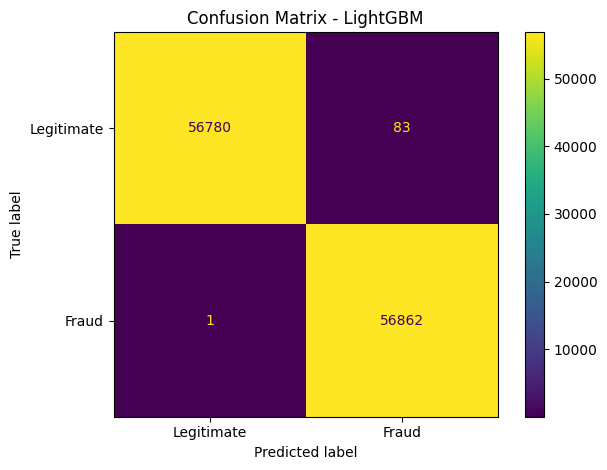

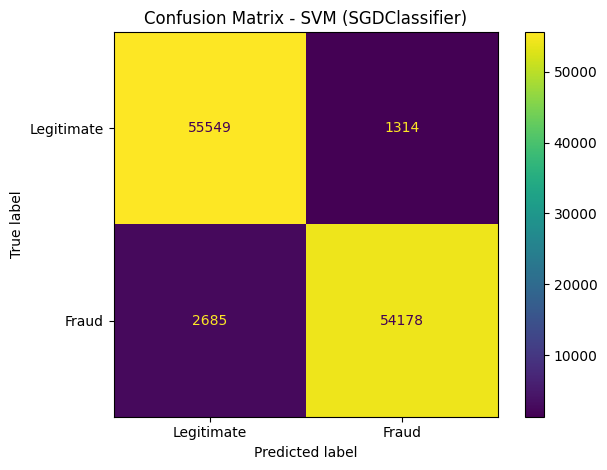

In [ ]:
for name in trained_models:

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name],
        display_labels=['Legitimate', 'Fraud']
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

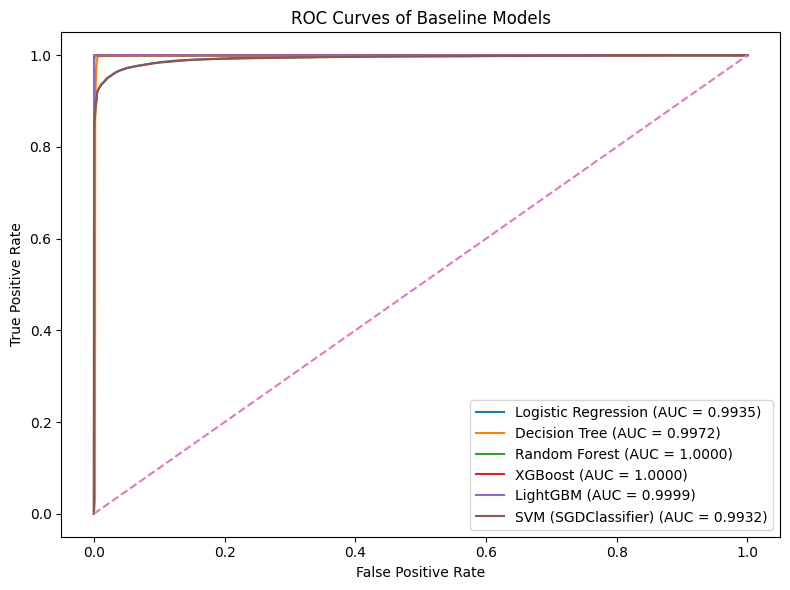

In [ ]:
plt.figure(figsize=(8, 6))

for name in trained_models:

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[name]
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {auc_score:.4f})'
    )

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves of Baseline Models')
plt.legend()
plt.tight_layout()
plt.show()